# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, ttest_ind, fisher_exact
from functions import plot, preprocessing, plot_volcano, format_compound_names, format_dataframe, ttest_for_df
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from adjustText import adjust_text
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import re

# Variables

In [3]:
data_names = ["wt_1h", "wt_4h", "wt_24h"]
log_trans = True

# Format data

In [4]:
df = format_dataframe("wt_24h", save=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h26:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing

## Add labeled and unlabeled

In [5]:
for col in [c for c in df.columns[1:] if "_l" not in c]:
    col_l = col + "_l"
    df[f"{"sum_" + col}"] = df[[col, col_l]].sum(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h26:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Filter not detected compounds

In [6]:
rows_to_drop = []

for i, r in df.filter(regex="sum").iterrows():
    if np.all(r.values == 0):
        rows_to_drop.append(i)

print(rows_to_drop)
df = df.drop(index=rows_to_drop, axis=1)
df    

[78, 92, 96, 100, 104, 110, 170, 176]


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.141680,0.155408,1.477405,1.646680,1.324467,1.301605,1.369899,1.383700,1.477822,1.185511
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.783860,0.945204,15.583452,15.040617,14.501592,17.340614,13.193404,13.329697,15.536822,12.832825
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922


## Replace zero values
- replace zero values with half minimum value, because log(0) not possible

In [7]:
half_min = np.min([val for val in df.filter(regex=r"^(?!.*compound).*$").values.flatten() if val != 0]) / 2
print("Half minimum:", half_min)

for col in df.columns:
    if col == "compound":
        continue
    
    if "sum" in col:
        #print(col)
        df[col] = df[col].replace(0, half_min)

df

Half minimum: 4.0672700112186134e-05


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.141680,0.155408,1.477405,1.646680,1.324467,1.301605,1.369899,1.383700,1.477822,1.185511
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.783860,0.945204,15.583452,15.040617,14.501592,17.340614,13.193404,13.329697,15.536822,12.832825
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922


## Relative values

In [8]:
cols = [c for c in df.columns[1:] if "sum" in c]


for exp in ["exp2", "exp4"]:
    for deg in ["22deg", "37deg"]:
        df_exp = df.filter(regex=rf"sum_{exp}_{deg}")
        summe = np.sum(df_exp.values.flatten())

        for col in df_exp.columns:
            df[col] = [val / summe for val in df[col].values]

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.003604,0.004081,0.001590,0.001459,0.001157,0.001279,0.003222,0.004775,0.004404,0.003232
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000074,0.000037,0.000045,0.000017,0.000018,0.000111,0.000032,0.000820,0.000034,0.000069
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.014774,0.014523,0.002634,0.002590,0.002039,0.002106,0.010172,0.010822,0.008723,0.007878
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.001352,0.001485,0.004013,0.003587,0.002798,0.002879,0.003255,0.003442,0.003727,0.002750
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.002170,0.002044,0.003410,0.003010,0.002695,0.002276,0.003900,0.004234,0.004073,0.003269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.000276,0.000303,0.000331,0.000369,0.000297,0.000292,0.000318,0.000321,0.000343,0.000275
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.001529,0.001844,0.003496,0.003374,0.003253,0.003890,0.003064,0.003096,0.003609,0.002981
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.011343,0.013730,0.018691,0.017060,0.016943,0.019491,0.014722,0.016115,0.018810,0.013980
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000196,0.000238,0.000712,0.000627,0.000766,0.000827,0.000552,0.000602,0.000865,0.000563


In [9]:
df.filter(regex="sum_exp4.*37deg").to_numpy().sum()

np.float64(1.0)

## log Transformation

In [10]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "sum" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = np.log(df[col].values)

df

['sum_exp2_22deg_1', 'sum_exp2_22deg_2', 'sum_exp2_22deg_3', 'sum_exp2_22deg_4', 'sum_exp2_37deg_1', 'sum_exp2_37deg_2', 'sum_exp2_37deg_3', 'sum_exp2_37deg_4', 'sum_exp4_22deg_1', 'sum_exp4_22deg_2', 'sum_exp4_22deg_3', 'sum_exp4_22deg_4', 'sum_exp4_37deg_1', 'sum_exp4_37deg_2', 'sum_exp4_37deg_3', 'sum_exp4_37deg_4']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.625677,-5.501447,-6.443959,-6.529835,-6.762250,-6.661362,-5.737900,-5.344391,-5.425277,-5.734672
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-9.515163,-10.200600,-10.012870,-10.956842,-10.908775,-9.107479,-10.341765,-7.106206,-10.302609,-9.586158
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.214913,-4.232047,-5.939280,-5.956032,-6.195069,-6.162845,-4.588092,-4.526137,-4.741797,-4.843708
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-6.606371,-6.512628,-5.518314,-5.630343,-5.878741,-5.850193,-5.727610,-5.671766,-5.592041,-5.896245
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-6.132837,-6.192775,-5.681104,-5.805851,-5.916346,-6.085199,-5.546718,-5.464711,-5.503346,-5.723152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,-8.193656,-8.101173,-8.012050,-7.903575,-8.121326,-8.138738,-8.052914,-8.042890,-7.977082,-8.197477
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,-6.482996,-6.295826,-5.656127,-5.691582,-5.728078,-5.549285,-5.787934,-5.777657,-5.624438,-5.815645
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-4.479138,-4.288164,-3.979708,-4.071047,-4.077924,-3.937789,-4.218397,-4.128029,-3.973376,-4.270144
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-8.538412,-8.343783,-7.246991,-7.375330,-7.174685,-7.097425,-7.501970,-7.414744,-7.053291,-7.481852


## Statistics

### Mean and Std

In [11]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df[f"mean_{g}"] = df.filter(regex=g).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=g).std(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp4_37deg_3,sum_exp4_37deg_4,mean_sum_exp2_22deg,sd_sum_exp2_22deg,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.425277,-5.734672,-6.362647,0.084257,-5.550309,0.059035,-6.599352,0.121820,-5.560560,0.178041
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-10.302609,-9.586158,-14.836869,2.903952,-9.757173,0.301133,-10.246492,0.757487,-9.334184,1.321026
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.741797,-4.843708,-5.946940,0.208879,-4.295000,0.071904,-6.063306,0.116361,-4.674933,0.125137
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-5.592041,-5.896245,-5.596816,0.088864,-6.608853,0.066664,-5.719398,0.150717,-5.721916,0.111586
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-5.503346,-5.723152,-6.130192,0.235836,-6.243511,0.084530,-5.872125,0.148524,-5.559482,0.098848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,-7.977082,-8.197477,-8.422332,0.146130,-8.219605,0.094839,-8.043922,0.094465,-8.067591,0.080449
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,-5.624438,-5.815645,-6.670297,0.059217,-6.382789,0.067947,-5.656268,0.066800,-5.751418,0.074617
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-3.973376,-4.270144,-4.607416,0.067550,-4.404221,0.071068,-4.016617,0.059786,-4.147487,0.112657
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-7.053291,-7.481852,-8.689808,0.131342,-8.397058,0.087121,-7.223608,0.102325,-7.362964,0.181683


### T-test

In [12]:
df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_22deg").columns, df.filter(regex=r"^sum_exp2_37deg").columns, "exp2")
df = ttest_for_df(df, df.filter(regex=r"^sum_exp4_22deg").columns, df.filter(regex=r"^sum_exp4_37deg").columns, "exp4")

df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_22deg").columns, df.filter(regex=r"^sum_exp4_22deg").columns, "22deg")
df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_37deg").columns, df.filter(regex=r"^sum_exp4_37deg").columns, "37deg")

df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000410,-8.340296,0.000303,0.004410,2.767923,0.036798,0.055197,0.094664,0.929545,0.929545
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.091772,-1.037674,0.349033,0.452026,-2.649266,0.067408,0.093334,-0.540726,0.622978,0.641035
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.003610,-14.072814,0.000008,0.000331,0.842955,0.440043,0.465928,4.559607,0.006740,0.011394
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000290,0.023255,0.982263,0.993146,1.213494,0.280590,0.325846,-11.818669,0.000087,0.000740
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.500054,-3.035219,0.027347,0.063543,-1.603776,0.169020,0.206262,-9.109290,0.000113,0.000740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.136326,0.330392,0.752611,0.825782,-3.766718,0.012441,0.024589,-2.117149,0.079818,0.101198
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.009698,1.645587,0.151551,0.225897,-19.674751,0.000001,0.000046,-10.836184,0.000039,0.000645
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.031715,1.777302,0.141216,0.218746,-11.343861,0.000031,0.000320,-3.338421,0.020212,0.029906
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.044387,1.157570,0.302138,0.404558,-15.252782,0.000008,0.000118,-8.889219,0.000624,0.001978


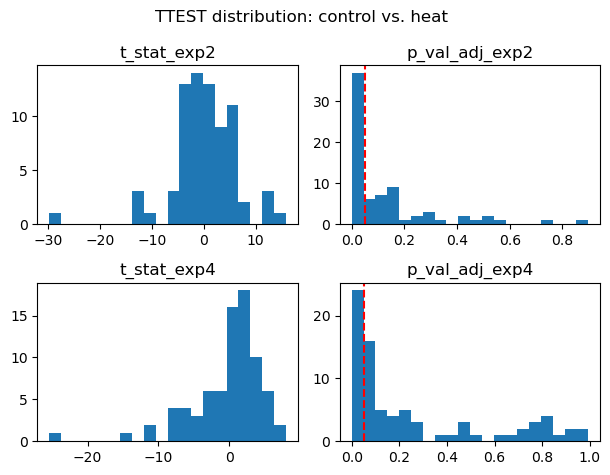

In [13]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df, [["t_stat_exp2", "p_val_adj_exp2"], ["t_stat_exp4", "p_val_adj_exp4"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

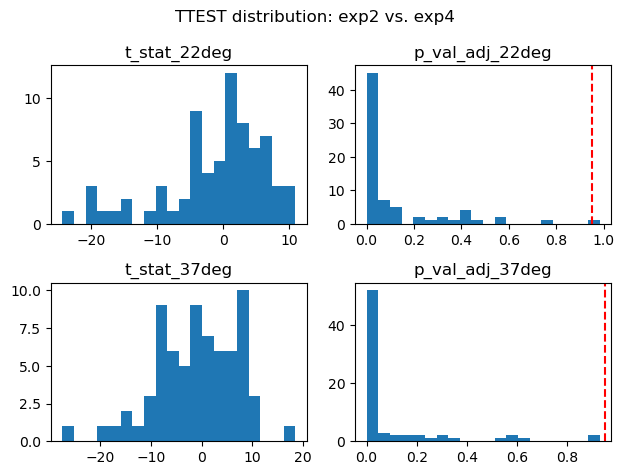

In [14]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df, [["t_stat_22deg", "p_val_adj_22deg"], ["t_stat_37deg", "p_val_adj_37deg"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

-> no significant differences expected between exp2 and exp4

### Fold change

In [15]:
## fold change between 22deg and 37deg
df["log2_fc_exp2"] = df["mean_sum_exp2_37deg"] - df["mean_sum_exp2_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["log2_fc_exp4"] = df["mean_sum_exp4_37deg"] - df["mean_sum_exp4_22deg"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000303,0.004410,2.767923,0.036798,0.055197,0.094664,0.929545,0.929545,0.812339,1.038791
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.349033,0.452026,-2.649266,0.067408,0.093334,-0.540726,0.622978,0.641035,5.079696,0.912307
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000008,0.000331,0.842955,0.440043,0.465928,4.559607,0.006740,0.011394,1.651939,1.388373
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.982263,0.993146,1.213494,0.280590,0.325846,-11.818669,0.000087,0.000740,-1.012037,-0.002518
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.027347,0.063543,-1.603776,0.169020,0.206262,-9.109290,0.000113,0.000740,-0.113320,0.312643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.752611,0.825782,-3.766718,0.012441,0.024589,-2.117149,0.079818,0.101198,0.202727,-0.023668
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.151551,0.225897,-19.674751,0.000001,0.000046,-10.836184,0.000039,0.000645,0.287508,-0.095150
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.141216,0.218746,-11.343861,0.000031,0.000320,-3.338421,0.020212,0.029906,0.203195,-0.130870
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.302138,0.404558,-15.252782,0.000008,0.000118,-8.889219,0.000624,0.001978,0.292750,-0.139357


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


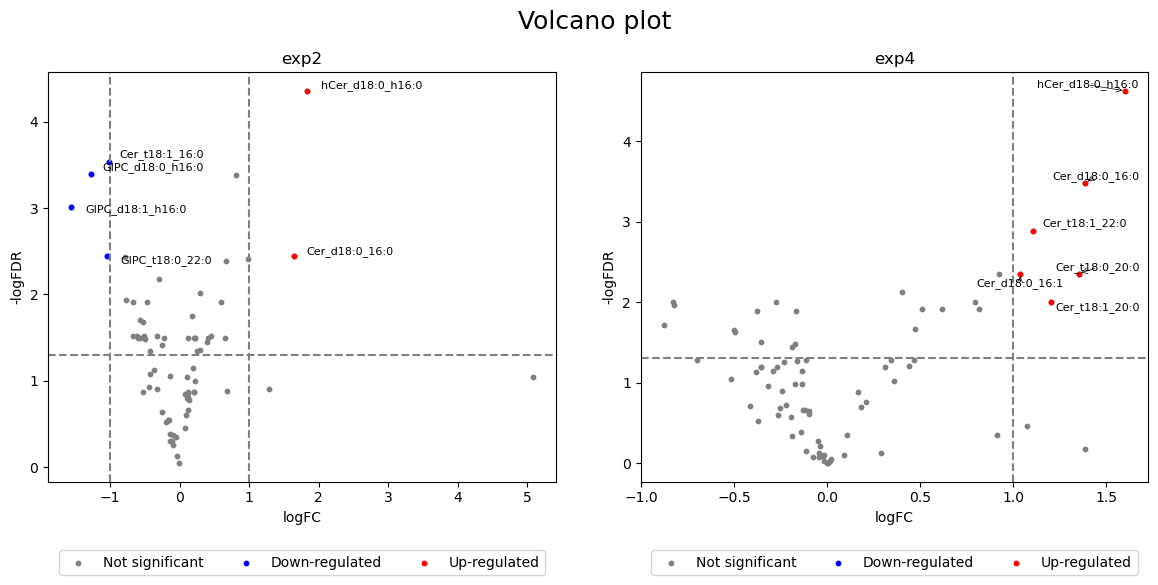

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, exp in enumerate(["exp2", "exp4"]):
    df_volcano = df[["compound", f"log2_fc_{exp}", f"p_val_adj_{exp}"]]
    df_volcano.columns = ["compounds", "log2_fc", "p_val_adj"]

    plot_volcano(df_volcano, compounds_col="compounds", fcr_col="p_val_adj", fc_col="log2_fc", significance=0.05, fc_level=1, title=exp, ax=axs[i])

plt.suptitle("Volcano plot", fontsize=18)
plt.tight_layout()
plt.show()

### Skewness

In [17]:
df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_37deg"] = [skew(df.filter(regex=r".*sum_exp4_37deg_\d+$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_37992\1238662511.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_37992\1238662511.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_37992\1238662511.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.055197,0.094664,0.929545,0.929545,0.812339,1.038791,-1.152613,-0.106051,-0.065406,0.076271
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.093334,-0.540726,0.622978,0.641035,5.079696,0.912307,1.154701,-0.408453,0.484035,0.988173
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.465928,4.559607,0.006740,0.011394,1.651939,1.388373,0.496364,0.010612,-0.020859,-0.147625
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.325846,-11.818669,0.000087,0.000740,-1.012037,-0.002518,0.545281,0.094276,0.186472,-0.536461
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.206262,-9.109290,0.000113,0.000740,-0.113320,0.312643,0.702666,0.106714,-0.190678,-0.868226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.024589,-2.117149,0.079818,0.101198,0.202727,-0.023668,0.030198,-0.417549,0.439124,-0.687384
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.000046,-10.836184,0.000039,0.000645,0.287508,-0.095150,-1.016511,-0.265049,0.679441,1.032467
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000320,-3.338421,0.020212,0.029906,0.203195,-0.130870,-0.930465,0.771972,0.173642,0.539157
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000118,-8.889219,0.000624,0.001978,0.292750,-0.139357,-0.830446,-0.763138,-0.321824,1.050152


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_exp2_22deg'}>,
         <Axes: title={'center': 'skew_exp2_37deg'}>],
        [<Axes: title={'center': 'skew_exp4_22deg'}>,
         <Axes: title={'center': 'skew_exp4_37deg'}>]], dtype=object))

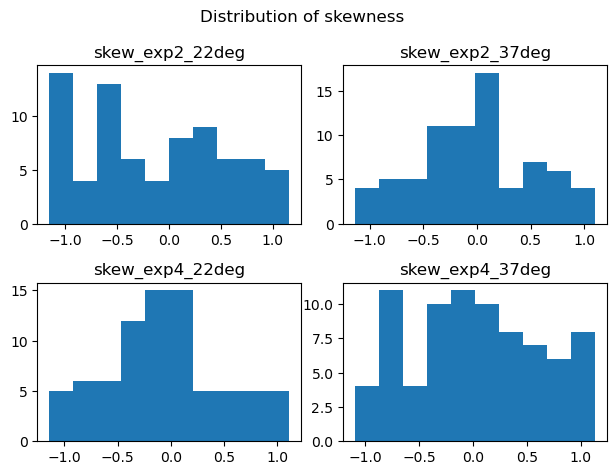

In [23]:
plot(2, 2, "Distribution of skewness", df, [["skew_exp2_22deg", "skew_exp2_37deg"], ["skew_exp4_22deg", "skew_exp4_37deg"]], 10)

## Save results
for every component:
- expX_Xdeg_X -> raw absolute values
- expX_Xdeg_X_l -> raw absolute values labeled
- sum_expX_Xdeg_X -> sum of absolute unlabeled + labeled, relative values, log transformation
- mean_sum_expX_Xdeg -> mean of sum_expX_Xdeg_1-4
- sd_sum_expX_Xdeg -> standard deviation of sum_expX_Xdeg_1-4
- t_stat_expX, p_val_expX, p_val_adj_expX -> t_value, p_value and Benjamin-Hochberg adjusted p_value of control vs. heat
- t_stat_Xdeg, p_val_Xdeg, p_val_adj_Xdeg -> t_value, p_value and Benjamin-Hochberg adjusted p_value of exp2 vs. exp4
- log2_fc_expX -> log2 difference between control and heat
- skew_expX_Xdeg -> skewness of sum_expX_Xdeg_1-4 values

In [24]:
df.to_csv(f"../data/preprocessed/{data_name}.csv", index=False)

# Principle component analysis

## Centering and scaling
- x scaled = (x - mean(x)) / std(x)

In [25]:
df_pca = df.filter(regex=r"^sum_exp\d+_\d+deg_\d+").T
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

df_pca_scaled

array([[-0.60291842, -1.98267304, -0.47884615, ..., -1.7599867 ,
        -1.52162478, -1.2125744 ],
       [-0.61121862, -1.98267304, -0.90249437, ..., -1.09872134,
        -1.06453886, -1.08706538],
       [-1.01046268, -1.98267304, -1.21571706, ..., -1.2577734 ,
        -0.99509911, -1.20318718],
       ...,
       [ 1.38862181,  1.42724434,  0.91526463, ...,  0.68496324,
         0.77622944,  0.95990943],
       [ 1.22193178,  0.26862101,  0.64070114, ...,  1.32346862,
         1.33334222,  1.42467646],
       [ 0.58432995,  0.52831828,  0.5109547 , ...,  0.09822507,
         0.67279568,  0.72099955]], shape=(16, 82))

## PCA

In [26]:
pca = PCA(n_components=2)
scores = pca.fit_transform(df_pca_scaled)
scores

array([[ 8.47339753, -3.74419606],
       [ 8.51646847, -4.05768313],
       [ 8.40221999, -3.80940557],
       [ 6.16124799, -3.11418203],
       [ 5.69829169,  5.08222046],
       [ 6.2800306 ,  5.01470335],
       [ 5.75084338,  4.43450694],
       [ 5.06164256,  4.32766152],
       [-6.10407576, -4.35706418],
       [-6.43058911, -3.90340805],
       [-5.15163084, -3.43019672],
       [-6.91302297, -4.37507217],
       [-6.81007142,  2.33679214],
       [-8.08117885,  3.57505671],
       [-8.18786911,  3.32501791],
       [-6.66570414,  2.69524887]])

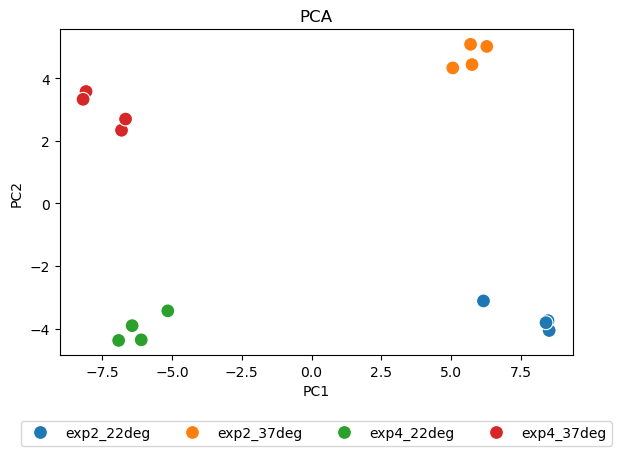

In [27]:
# PCA scores in DataFrame
df_pca_plot = pd.DataFrame(scores, columns=['PC1', 'PC2'])

# add groups
groups = ["exp2_22deg"]*4 + ["exp2_37deg"]*4 + ["exp4_22deg"]*4 + ["exp4_37deg"]*4
df_pca_plot['group'] = groups

# Plot
sns.scatterplot(data=df_pca_plot, x="PC1", y="PC2", hue="group", s=100)
plt.title("PCA")
plt.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.3))
plt.tight_layout()

# Batch correction
## Linear model
y = µ + ß1 * condition + ß2 * batch + e  

Where:

y = measured intensity of the metabolite (log-transformed)  
μ = intercept (mean of the reference group)  
β1= effect of the experimental condition (e.g., temperature)  
β2 = batch effect (e.g., experiment 2 vs 4)  
e = residual error (assumed normally distributed, mean 0)


In [4]:
batch_df = preprocessing(pd.read_csv("../data/formated/wt_24h.csv"), replace_zero="half_min_loc", relative_values=False)
batch_df_t = batch_df.filter(regex="sum").T
batch_df_t.columns = batch_df["compound"].values
batch_df_t

c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavio

,Cer_d18:0_16:1,Cer_d18:1_16:0,Cer_d18:0_16:0,Cer_t18:1_16:0,Cer_t18:0_16:0,Cer_d18:1_18:0,Cer_t18:1_20:0,Cer_t18:0_20:0,Cer_t18:1_22:0,Cer_t18:0_22:0,...,GIPC_t18:0_h24:0,GIPC_t18:1_26:0,GIPC_t18:0_h25:1,GIPC_t18:1_h25:0,GIPC_t18:0_26:0,GIPC_t18:0_h25:0,GIPC_t18:1_h26:1,GIPC_t18:1_h26:0,GIPC_t18:1_h28:1,GIPC_t18:1_h28:0
sum_exp2_22deg_1,0.092731,-4.654275,0.782351,0.942862,0.649516,-4.117116,-2.151942,-2.934575,-0.053122,-0.074999,...,1.018279,-1.357300,-3.363699,-1.061456,-0.996533,-2.173662,-0.367303,1.683289,-2.502072,-1.611714
sum_exp2_22deg_2,0.088703,-4.654275,0.449590,0.828613,0.296077,-5.418856,-2.321406,-3.218404,-0.221238,-0.231563,...,1.149145,-1.605531,-3.363699,-1.116204,-1.154694,-1.850766,-0.215204,1.843455,-2.205516,-1.532199
sum_exp2_22deg_3,-0.105029,-4.654275,0.203565,0.721680,0.094497,-3.510524,-2.477164,-3.159821,-0.264665,-0.418389,...,1.064130,-1.668962,-3.363699,-1.242816,-1.176729,-2.154090,-0.248010,1.804931,-2.160464,-1.605767
sum_exp2_22deg_4,0.087056,-3.403564,0.390786,0.733633,0.053194,-3.035698,-2.906974,-3.285317,-0.499275,-0.660323,...,1.042944,-1.572086,-3.363699,-1.149698,-1.160904,-1.896759,-0.236619,1.852713,-2.277129,-1.546659
sum_exp2_37deg_1,0.754959,-3.625850,1.879002,-0.376077,-0.065621,-2.906833,-2.768520,-2.346729,-0.058561,0.136061,...,1.093558,-1.721054,-3.363699,-1.339512,-1.356255,-1.978653,-0.117007,1.802964,-2.070756,-1.303217
sum_exp2_37deg_2,0.649874,-3.208135,1.866899,-0.461393,-0.103869,-2.752544,-2.647939,-2.278411,0.077816,0.142035,...,1.010944,-1.897404,-3.363699,-1.554666,-1.430731,-2.125997,-0.156385,1.826397,-2.156338,-1.473851
sum_exp2_37deg_3,0.613795,-3.275692,2.024559,-0.366900,0.106634,-2.494576,-2.898785,-2.393303,-0.110410,0.146985,...,1.004812,-1.682122,-3.363699,-1.474520,-1.314530,-1.954185,-0.243525,1.760333,-2.298940,-1.675171
sum_exp2_37deg_4,0.738024,-3.961128,2.007425,-0.273156,0.046696,-3.426836,-2.739131,-2.327182,-0.043122,0.132096,...,1.018560,-1.683230,-3.363699,-1.433184,-1.242273,-1.861701,-0.056355,1.951307,-2.104312,-1.591980
sum_exp4_22deg_1,1.958377,-1.610534,2.463056,2.884022,2.721232,-1.025315,0.114517,-0.960630,1.570058,1.629598,...,3.435253,2.216525,-1.764792,1.813524,1.774969,0.390287,2.746210,4.422629,1.155345,1.815722
sum_exp4_22deg_2,1.872502,-2.554505,2.446304,2.771994,2.596486,-2.024252,-0.134218,-0.853049,1.540183,1.490501,...,3.340692,1.996641,-1.495785,1.733496,1.600970,0.498761,2.710754,4.331290,1.027007,1.705050


In [5]:
samples = batch_df.filter(regex="sum").columns
results = []

for metabolite in batch_df_t.columns:
    
    df_model = pd.DataFrame({
        "sample": samples,
        "y": batch_df_t[metabolite].values
    })
    
    df_model["batch"] = df_model["sample"].str.extract(r"(exp\d+)")
    df_model["condition"] = df_model["sample"].str.extract(r"_(\d+deg)")
    
    model = smf.ols("y ~ C(condition) + C(batch)", data=df_model).fit()
    
    # Condition-Effekt automatisch extrahieren
    condition_param = [p for p in model.params.index if "C(condition)" in p]
    
    if len(condition_param) > 0:
        coef = model.params[condition_param[0]]
        pval = model.pvalues[condition_param[0]]
    else:
        coef = np.nan
        pval = np.nan
    
    # Batch-Effekt extrahieren
    batch_param = [p for p in model.params.index if "C(batch)" in p]
    
    if len(batch_param) > 0:
        batch_pval = model.pvalues[batch_param[0]]
    else:
        batch_pval = np.nan
    
    results.append({
        "compound": metabolite,
        "EffectSize_condition": coef,
        "p_val_condition": pval,
        "p_val_batch": batch_pval,
        "R2": model.rsquared
    })

results_df = pd.DataFrame(results)

# FDR-Korrektur
results_df["p_val_adj_condition"] = multipletests(
    results_df["p_val_condition"],
    method="fdr_bh"
)[1]

- Effect size condition: 1 = 2-fold upregulated in 37deg compared to 22deg
- p-value condition: significant temperature-regulated metabolites  
- p-value batch: significant batch effect  
- R2: high values mean clear differentiation between groups, low spread within groups, consistent replicates

## Categorize compounds

In [6]:
sign_lvl_cond = 0.05
sign_lvl_batch = 0.05
effect_size = 0.3
categories = []

for i, r in results_df.iterrows():
    if r["p_val_adj_condition"] < sign_lvl_cond and abs(r["EffectSize_condition"]) > effect_size:
        if r["p_val_batch"] < sign_lvl_batch:
            categories.append("both")
        else:
            categories.append("condition")
    
    elif r["p_val_batch"] < sign_lvl_batch:
        categories.append("batch")
    
    else:
        categories.append("neutral")

results_df["category"] = categories
print(f"{len(results_df[results_df["category"] == "both"])} compounds show both significant temperature and batch effect,")
print(f"{len(results_df[results_df["category"] == "condition"])} compounds show significant temperature effect,")
print(f"{len(results_df[results_df["category"] == "batch"])} compounds show significant batch effect,")
print(f"{len(results_df[results_df["category"] == "neutral"])} compounds show no significant effect.")
results_df

31 compounds show both significant temperature and batch effect,
0 compounds show significant temperature effect,
51 compounds show significant batch effect,
0 compounds show no significant effect.


,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category
0,Cer_d18:0_16:1,0.826202,1.803235e-07,4.983504e-12,0.980425,2.957306e-06,both
1,Cer_d18:1_16:0,0.850759,8.482788e-02,9.620912e-05,0.724108,1.264707e-01,batch
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278259e-12,0.984712,6.576588e-09,both
3,Cer_t18:1_16:0,-0.606641,3.311329e-03,2.164134e-09,0.944687,9.697464e-03,both
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102142e-11,0.973969,9.979675e-01,batch
...,...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740465e-01,9.433566e-15,0.991209,9.263576e-01,batch
78,GIPC_t18:1_h26:1,-0.003185,9.514305e-01,6.490141e-17,0.995912,9.631765e-01,batch
79,GIPC_t18:1_h26:0,-0.063201,2.533927e-01,6.614981e-16,0.994161,3.196647e-01,batch
80,GIPC_t18:1_h28:1,-0.022667,7.909697e-01,6.192559e-15,0.991760,8.764799e-01,batch


## Volcano plot

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


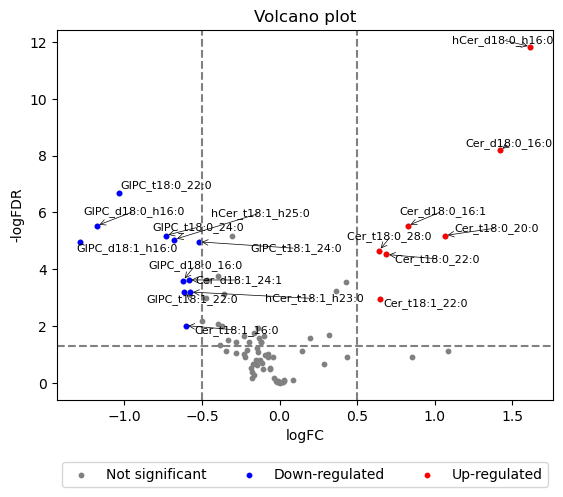

In [7]:
fig, ax = plot_volcano(results_df, compounds_col="compound", fcr_col="p_val_adj_condition", fc_col="EffectSize_condition", title="Volcano plot", significance=0.05, fc_level=0.5)

# Enrichment Analysis

## Add features

In [8]:
## Significance
results_df["significant"] = results_df["p_val_adj_condition"] < 0.05

In [9]:
## Compound class
def extract_class(compound_name):    
    cls = compound_name.split("_")[0]

    if cls == "Cer":
        return "Ceramide"
    elif cls == "hCer":
        return "Hydroxy_ceramide"
    elif cls == "GlcCer":
        return "Glycosyl_ceramide"
    elif cls == "GIPC":
        return "GIPC"
    else:
        return ("no class")
    
results_df["class"] = results_df["compound"].apply(extract_class) 

In [10]:
## add chain length
def extract_chain_length(compound_name):
    match = re.search(r'(?:h)?(\d+):', compound_name.split("_")[-1])

    if match:
        return int(match.group(1))
    else:
        return None

results_df["chain_length"] = results_df["compound"].apply(extract_chain_length)

In [11]:
## categorize chain-length
def categorize_chain_length(length):
    if length is None:
        return None
    elif length <= 16:
        return "short"
    # elif 20 <= length <= 22:
    #     return "long"
    elif length >= 18:
        return "very_long"

results_df["chain_category"] = results_df["chain_length"].apply(categorize_chain_length)

In [12]:
## add Hydroxylation of sphingo base
def extract_sphingo_hydroxylation(compound_name):
    hydroxy = compound_name.split("_")[1][0]

    if hydroxy == "d":
        return 2
    elif hydroxy == "t":
        return 3

results_df["sphingo_hydroxylation"] = results_df["compound"].apply(extract_sphingo_hydroxylation)

In [13]:
## add Hydroxylation of fatty acid
def extract_fatty_hydroxylation(compound_name):
    hydroxy = compound_name.split("_")[-1][0]

    if hydroxy == "h":
        return True
    else:
        return False

results_df["fatty_hydroxylation"] = results_df["compound"].apply(extract_fatty_hydroxylation)

In [14]:
## add double bounds
def extract_double_bounds(compound_name):
    dbs = compound_name.split("_")[-1].split(":")[-1]
    return int(dbs)

results_df["double_bounds"] = results_df["compound"].apply(extract_double_bounds)
results_df

,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category,significant,class,chain_length,chain_category,sphingo_hydroxylation,fatty_hydroxylation,double_bounds
0,Cer_d18:0_16:1,0.826202,1.803235e-07,4.983504e-12,0.980425,2.957306e-06,both,True,Ceramide,16,short,2,False,1
1,Cer_d18:1_16:0,0.850759,8.482788e-02,9.620912e-05,0.724108,1.264707e-01,batch,False,Ceramide,16,short,2,False,0
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278259e-12,0.984712,6.576588e-09,both,True,Ceramide,16,short,2,False,0
3,Cer_t18:1_16:0,-0.606641,3.311329e-03,2.164134e-09,0.944687,9.697464e-03,both,True,Ceramide,16,short,3,False,0
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102142e-11,0.973969,9.979675e-01,batch,False,Ceramide,16,short,3,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740465e-01,9.433566e-15,0.991209,9.263576e-01,batch,False,GIPC,25,very_long,3,True,0
78,GIPC_t18:1_h26:1,-0.003185,9.514305e-01,6.490141e-17,0.995912,9.631765e-01,batch,False,GIPC,26,very_long,3,True,1
79,GIPC_t18:1_h26:0,-0.063201,2.533927e-01,6.614981e-16,0.994161,3.196647e-01,batch,False,GIPC,26,very_long,3,True,0
80,GIPC_t18:1_h28:1,-0.022667,7.909697e-01,6.192559e-15,0.991760,8.764799e-01,batch,False,GIPC,28,very_long,3,True,1


In [15]:
results_df.to_csv("test.csv", index=False)

## Overrepresentation analysis

In [16]:
def overrepresentation_analysis(df, ora_col):
    total = len(df)
    sig_total = df["significant"].sum()
    ora_results = []

    for cls in df[ora_col].unique():
        mask = df[ora_col] == cls

        class_total = mask.sum()
        class_sig = df[mask]["significant"].sum()

        a = class_sig
        b = class_total - class_sig
        c = sig_total - class_sig
        d = total - class_total - c
        
        table = [[a, b], [c, d]]
        oddsratio, pvalue = fisher_exact(table, alternative="greater")
        ora_results.append([cls, class_total, class_sig, oddsratio, pvalue])

    ora_df = pd.DataFrame(ora_results, columns=[ora_col, "n_total", "n_significant", "odds_ratio", "p_value"])
    ora_df["p_adj"] = multipletests(ora_df["p_value"], method="fdr_bh")[1]
    return ora_df

ora_class = overrepresentation_analysis(results_df, "class")
ora_class

,class,n_total,n_significant,odds_ratio,p_value,p_adj
0,Ceramide,21,11,1.136667,0.500000,0.666667
1,Hydroxy_ceramide,23,12,1.128527,0.500000,0.666667
2,Glycosyl_ceramide,6,5,5.555556,0.100587,0.402348
3,GIPC,32,13,0.537594,0.943799,0.943799


In [17]:
ora_chain_length = overrepresentation_analysis(results_df, "chain_category")
ora_chain_length

,chain_category,n_total,n_significant,odds_ratio,p_value,p_adj
0,short,18,11,1.780952,0.212059,0.424118
1,very_long,64,30,0.561497,0.909330,0.909330


In [18]:
ora_sphingo_hydr = overrepresentation_analysis(results_df, "sphingo_hydroxylation")
ora_sphingo_hydr

,sphingo_hydroxylation,n_total,n_significant,odds_ratio,p_value,p_adj
0,2,14,8,1.414141,0.385058,0.770117
1,3,68,33,0.707143,0.810342,0.810342


In [19]:
ora_fatty_hydr = overrepresentation_analysis(results_df, "fatty_hydroxylation")
ora_fatty_hydr

,fatty_hydroxylation,n_total,n_significant,odds_ratio,p_value,p_adj
0,False,32,19,1.860140,0.128777,0.257554
1,True,50,22,0.537594,0.943799,0.943799


In [20]:
ora_dbs = overrepresentation_analysis(results_df, "double_bounds")
ora_dbs

,double_bounds,n_total,n_significant,odds_ratio,p_value,p_adj
0,1,19,8,0.661157,0.852429,0.852429
1,0,63,33,1.512500,0.300729,0.601459


## PCA with significant compounds

In [21]:
sig_metabolites = results_df.loc[results_df["p_val_adj_condition"] < 0.05, "compound"].tolist()
X = batch_df_t[sig_metabolites]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, 'PCA – significant metabolites only')

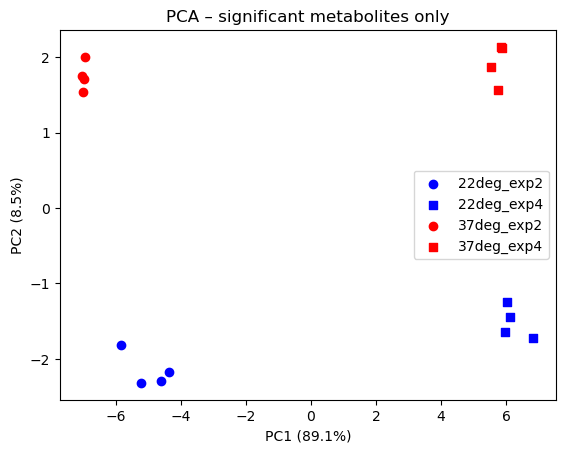

In [22]:
meta = pd.DataFrame(index=batch_df_t.index)
meta["batch"] = [meta.index[i].split("_")[1] for i in range(len(meta))]
meta["condition"] = [meta.index[i].split("_")[2] for i in range(len(meta))]

colors = {"22deg": "blue", "37deg": "red"}
markers = {"exp2": "o", "exp4": "s"}

for cond in meta["condition"].unique():
    for batch in meta["batch"].unique():
        
        idx = (meta["condition"] == cond) & (meta["batch"] == batch)
        
        plt.scatter(
            X_pca[idx,0],
            X_pca[idx,1],
            color=colors[cond],
            marker=markers[batch],
            label=f"{cond}_{batch}"
        )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.title("PCA – significant metabolites only")

# Mutant Analysis (sld 24h)

## Format data

In [20]:
df_sld_form = format_dataframe("sld_24h")
df_sld_form

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955687,3.749633,3.815411,3.620979,13.400314,...,3.167761,3.422592,5.725892,5.958604,5.244753,5.270445,32.887509,44.181303,35.490193,41.497261
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668387,...,0.601956,0.622684,10.840034,11.408771,12.210812,10.112965,12.145008,12.006661,12.810125,14.414790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.000000,0.000000,1.045956,0.948697,1.653506,1.267221,0.865090,0.523967,0.527134,0.880719
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
178,GIPC_t18:1_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
180,GIPC_t18:0_h28:1,0.070369,0.066726,0.082485,0.079501,0.094786,0.074484,0.087776,0.093676,3.488376,...,0.005815,0.000000,0.069398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Preprocessing

In [21]:
df_sld_pre = preprocessing(df_sld_form, add_unlabeled_labeled=True, replace_zero="half_min_glob", relative_values=True, log_transformation=True)
df_sld_pre

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-15.028356,-15.028356,-17.238340,-9.507838,-9.241803,-9.228131,-8.852866,-9.459789,-9.555129,-10.195842
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,-15.028356,-8.381977,-7.566427,-9.651114,-10.596221,-8.762278,-9.663562,-8.683702,-7.614850,-6.941196
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,-4.183883,-4.175272,-5.386312,-5.395754,-5.502853,-5.447865,-4.344139,-4.070091,-4.307175,-4.163670
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,-10.847615,-11.146297,-9.660490,-9.288462,-9.407348,-9.309682,-10.275954,-9.893719,-9.985072,-10.245273
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,-5.637837,-5.708320,-4.739829,-4.728137,-4.665377,-4.777550,-5.171987,-5.138353,-5.130189,-5.025510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,-6.548163,-6.658320,-5.775272,-5.753659,-5.934741,-5.794077,-6.150030,-6.167367,-6.104172,-6.106697
172,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,-8.721013,-8.571290,-8.351270,-8.432054,-8.318581,-8.413560,-8.446528,-8.646150,-8.478956,-8.604234
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,-5.399392,-5.438877,-5.308636,-5.330569,-5.327017,-5.301395,-5.424664,-5.380221,-5.256620,-5.339071
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,-6.272566,-6.308396,-6.228569,-6.415650,-6.374411,-6.377157,-6.684156,-6.726163,-6.473588,-6.523234


## Statistics

### Mean and SD

In [22]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df_sld_pre[f"mean_{g}"] = df_sld_pre.filter(regex=g).mean(axis=1)
    df_sld_pre[f"sd_{g}"] = df_sld_pre.filter(regex=g).std(axis=1)
    
df_sld_pre

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp4_37deg_3,sum_exp4_37deg_4,mean_sum_exp2_22deg,sd_sum_exp2_22deg,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-9.555129,-10.195842,-15.205391,0.000000,-15.028356,0.000000,-11.304028,3.427991,-9.515907,0.476084
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,-7.614850,-6.941196,-9.869134,0.911115,-13.366761,2.877966,-9.144011,1.118096,-8.225827,1.036858
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,-4.307175,-4.163670,-5.327623,0.105316,-4.201016,0.126445,-5.433196,0.046549,-4.221269,0.110283
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,-9.985072,-10.245273,-9.949013,0.138995,-10.912622,0.192497,-9.416495,0.147833,-10.100005,0.164183
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,-5.130189,-5.025510,-4.857757,0.122742,-5.662532,0.108119,-4.727723,0.040362,-5.116510,0.054824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,-6.104172,-6.106697,-6.714157,0.088093,-6.580340,0.054372,-5.814437,0.070915,-6.132066,0.027343
172,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,-8.478956,-8.604234,-8.963291,0.131219,-8.654277,0.054660,-8.378866,0.045903,-8.543967,0.083358
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,-5.256620,-5.339071,-5.785169,0.080083,-5.455820,0.040671,-5.316904,0.012226,-5.350144,0.061902
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,-6.473588,-6.523234,-6.697851,0.112080,-6.358228,0.077245,-6.348947,0.071387,-6.601786,0.105900


### T-test

In [23]:
## T-test per experiment and per condition
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp2_37deg").columns, "exp2")
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp4_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_37deg").columns, "exp4")

df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_22deg").columns, "22deg")
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_37deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_37deg").columns, "37deg")

df_sld_stat

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,-0.894889,0.434553,0.524043,NaN,NaN,NaN,NaN,NaN,NaN
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.167083,-1.042938,0.337382,0.431406,-0.870789,0.418648,0.479420,-2.910828,0.046963,0.074097
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.000777,-17.535870,0.000058,0.000649,1.588071,0.185252,0.237177,0.209074,0.841432,0.865821
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.005519,5.358551,0.001791,0.009313,-4.545499,0.003948,0.011678,-5.563120,0.001550,0.006114
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.002218,9.891335,0.000103,0.001001,-1.743116,0.163285,0.218740,-7.801518,0.000932,0.004292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.112300,7.238486,0.002187,0.010660,-13.779872,0.000013,0.000229,-12.757625,0.000117,0.000923
172,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.047296,3.005046,0.032656,0.065311,-7.281540,0.002482,0.008027,-1.916743,0.111420,0.164809
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.010333,0.912458,0.424359,0.524043,-10.011724,0.001743,0.006512,-2.471215,0.054718,0.084457
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.024882,3.428985,0.017218,0.040081,-4.547752,0.005864,0.015419,3.218335,0.020602,0.042558


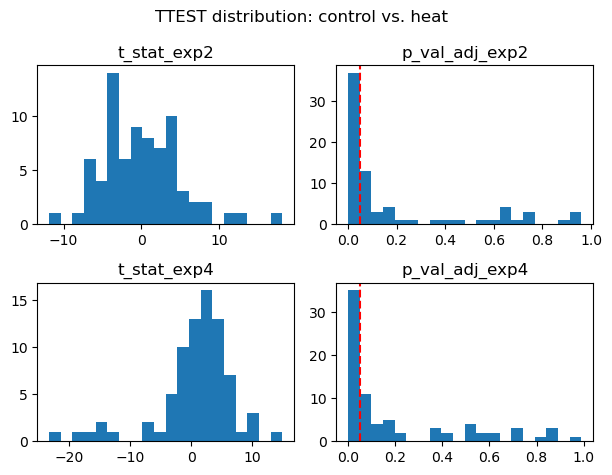

In [24]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df_sld_stat, [["t_stat_exp2", "p_val_adj_exp2"], ["t_stat_exp4", "p_val_adj_exp4"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

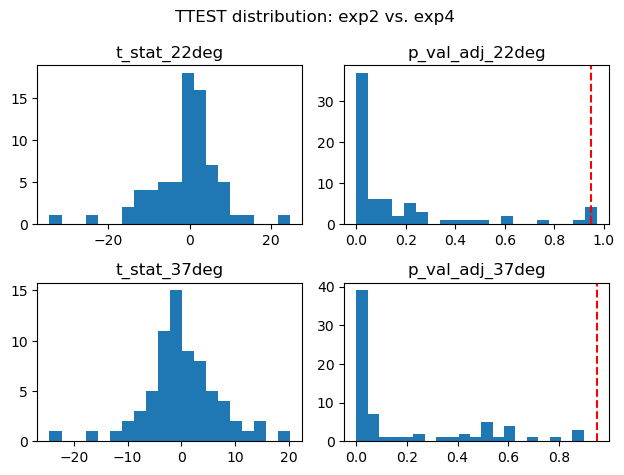

In [25]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df_sld_stat, [["t_stat_22deg", "p_val_adj_22deg"], ["t_stat_37deg", "p_val_adj_37deg"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

### Fold change

In [26]:
## fold change between 22deg and 37deg
df_sld_stat["log2_fc_exp2"] = df_sld_stat["mean_sum_exp2_37deg"] - df_sld_stat["mean_sum_exp2_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df_sld_stat["log2_fc_exp4"] = df_sld_stat["mean_sum_exp4_37deg"] - df_sld_stat["mean_sum_exp4_22deg"]
df_sld_stat

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.434553,0.524043,NaN,NaN,NaN,NaN,NaN,NaN,0.177035,1.788120
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.337382,0.431406,-0.870789,0.418648,0.479420,-2.910828,0.046963,0.074097,-3.497627,0.918183
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.000058,0.000649,1.588071,0.185252,0.237177,0.209074,0.841432,0.865821,1.126607,1.211927
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.001791,0.009313,-4.545499,0.003948,0.011678,-5.563120,0.001550,0.006114,-0.963610,-0.683510
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.000103,0.001001,-1.743116,0.163285,0.218740,-7.801518,0.000932,0.004292,-0.804775,-0.388787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.002187,0.010660,-13.779872,0.000013,0.000229,-12.757625,0.000117,0.000923,0.133816,-0.317629
172,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.032656,0.065311,-7.281540,0.002482,0.008027,-1.916743,0.111420,0.164809,0.309014,-0.165101
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.424359,0.524043,-10.011724,0.001743,0.006512,-2.471215,0.054718,0.084457,0.329349,-0.033240
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.017218,0.040081,-4.547752,0.005864,0.015419,3.218335,0.020602,0.042558,0.339623,-0.252839


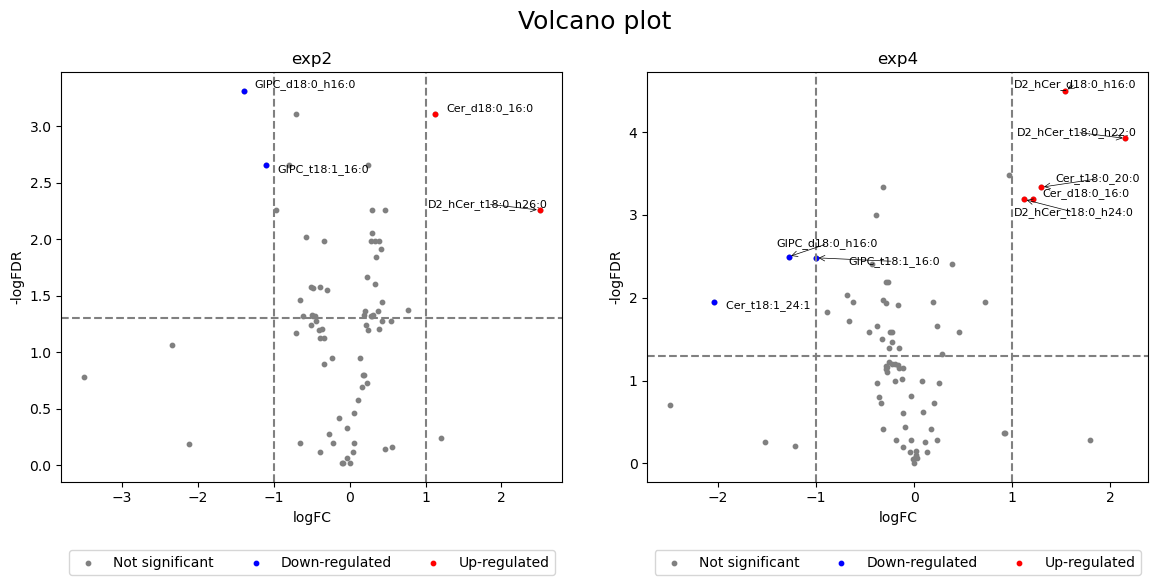

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, exp in enumerate(["exp2", "exp4"]):
    df_volcano = df_sld_stat[["compound", f"log2_fc_{exp}", f"p_val_adj_{exp}"]]
    df_volcano.columns = ["compounds", "log2_fc", "p_val_adj"]

    plot_volcano(df_volcano, compounds_col="compounds", fcr_col="p_val_adj", fc_col="log2_fc", significance=0.05, fc_level=1, title=exp, ax=axs[i])

plt.suptitle("Volcano plot", fontsize=18)
plt.tight_layout()
plt.show()

### Skewness

In [28]:
df_sld_stat["skew_exp2_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp2_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp4_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp4_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp4_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp4_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat

C:\Users\janni\AppData\Local\Temp\ipykernel_37992\4215796913.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_stat["skew_exp2_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
C:\Users\janni\AppData\Local\Temp\ipykernel_37992\4215796913.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_stat["skew_exp2_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
C:\Users\janni\AppData\Local\Temp\ipykernel_37992\4215796913.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_sta

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.177035,1.788120,NaN,NaN,-1.151065,-0.052676
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.479420,-2.910828,0.046963,0.074097,-3.497627,0.918183,0.801861,1.154701,0.141095,-0.161441
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.237177,0.209074,0.841432,0.865821,1.126607,1.211927,0.998984,-0.493436,-0.460011,0.215689
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.011678,-5.563120,0.001550,0.006114,-0.963610,-0.683510,-1.051639,0.271000,-0.867234,0.100773
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.218740,-7.801518,0.000932,0.004292,-0.804775,-0.388787,-0.285704,0.258778,0.444326,0.864514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.000229,-12.757625,0.000117,0.000923,0.133816,-0.317629,0.223359,-0.257210,-1.015177,-0.143761
172,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.008027,-1.916743,0.111420,0.164809,0.309014,-0.165101,0.402767,0.400414,0.123792,-0.037086
174,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.006512,-2.471215,0.054718,0.084457,0.329349,-0.033240,-1.078150,0.133308,0.097105,0.398785
176,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.015419,3.218335,0.020602,0.042558,0.339623,-0.252839,-0.919238,-0.465740,0.968006,0.022859


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_exp2_22deg'}>,
         <Axes: title={'center': 'skew_exp2_37deg'}>],
        [<Axes: title={'center': 'skew_exp4_22deg'}>,
         <Axes: title={'center': 'skew_exp4_37deg'}>]], dtype=object))

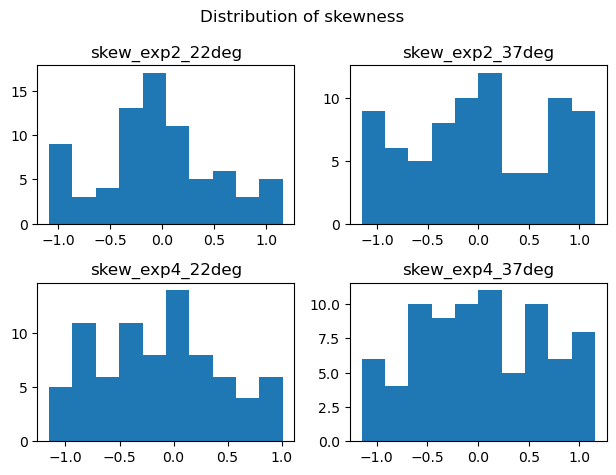

In [31]:
plot(2, 2, "Distribution of skewness", df_sld_stat, [["skew_exp2_22deg", "skew_exp2_37deg"], ["skew_exp4_22deg", "skew_exp4_37deg"]], 10)

# Longitudinal Analysis (exp2)

## Load and preprocess data

In [25]:
df = pd.DataFrame()
df_comps = []

for name in data_names:
    df_tp = format_dataframe(name, save=False)
    df_comps.append(df_tp["compound"].values)
    df_tp = df_tp[["compound"] + df_tp.filter(regex=r"exp2_22deg_\d+").columns.to_list()]
    df_tp = preprocessing(df_tp, add_unlabeled_labeled=True, replace_zero="half_min_loc", relative_values=False, log_transformation=False)
    df_tp["timepoint"] = name.split("_")[-1]
    df = pd.concat([df, df_tp])

df

c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavio

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_22deg_1_l,exp2_22deg_2_l,exp2_22deg_3_l,exp2_22deg_4_l,sum_exp2_22deg_1,sum_exp2_22deg_2,sum_exp2_22deg_3,sum_exp2_22deg_4,timepoint
0,Cer_d18:0_16:1,0.173378,0.188960,0.236601,0.170853,0.022714,0.043402,0.037110,0.050059,0.196092,0.232362,0.273711,0.220912,1h
2,Cer_d18:1_16:0,0.572601,5.706720,0.073125,0.018531,0.000000,0.030540,0.000000,0.000000,0.572601,5.737260,0.073125,0.018531,1h
4,Cer_d18:0_16:0,0.391096,0.486054,0.727939,0.546359,0.094174,0.140159,0.219855,0.174202,0.485269,0.626213,0.947795,0.720561,1h
6,Cer_t18:1_16:0,0.664432,0.624507,0.720180,0.529935,0.005966,0.033438,0.053770,0.045455,0.670398,0.657945,0.773950,0.575390,1h
8,Cer_t18:0_16:0,0.435893,0.385165,0.630758,0.390268,0.083210,0.084582,0.114095,0.127619,0.519104,0.469747,0.744853,0.517886,1h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.033843,0.033138,0.044222,0.048535,0.113760,0.157117,0.116009,0.150054,24h
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.000000,0.000000,0.000000,0.003366,0.692600,0.806377,0.780352,0.789292,24h
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,0.000000,0.000000,0.000000,0.000000,5.383232,6.318330,6.079550,6.377095,24h
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.000776,0.000000,0.000000,0.000000,0.081915,0.110194,0.115272,0.102578,24h


In [11]:
for i in range(len(df_comps[0])):
    if df_comps[0][i] != df_comps[1][i] != df_comps[2][i]:
        print(df_comps[0][i], df_comps[1][i], df_comps[2][i])

## Degree of labeling

In [24]:
replicates = 4

for i in range(1, replicates+1):
    df[f"dol_exp2_22deg_{i}"] = df[f"exp2_22deg_{i}"] / df[f"sum_exp2_22deg_{i}"]

df["mean_dol_exp2_22deg"] = df.filter(regex=r"dol_").mean(axis=1)
df["sd_dol_exp2_22deg"] = df.filter(regex=r"dol_").std(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_22deg_1_l,exp2_22deg_2_l,exp2_22deg_3_l,exp2_22deg_4_l,sum_exp2_22deg_1,sum_exp2_22deg_2,sum_exp2_22deg_3,sum_exp2_22deg_4,timepoint,dol_exp2_22deg_1,dol_exp2_22deg_2,dol_exp2_22deg_3,dol_exp2_22deg_4,mean_dol_exp2_22deg,sd_dol_exp2_22deg
0,Cer_d18:0_16:1,0.173378,0.188960,0.236601,0.170853,0.022714,0.043402,0.037110,0.050059,0.196092,0.232362,0.273711,0.220912,1h,0.884168,0.813214,0.864420,0.773397,0.833800,0.043436
2,Cer_d18:1_16:0,0.572601,5.706720,0.073125,0.018531,0.000000,0.030540,0.000000,0.000000,0.572601,5.737260,0.073125,0.018531,1h,1.000000,0.994677,1.000000,1.000000,0.998669,0.002305
4,Cer_d18:0_16:0,0.391096,0.486054,0.727939,0.546359,0.094174,0.140159,0.219855,0.174202,0.485269,0.626213,0.947795,0.720561,1h,0.805935,0.776180,0.768035,0.758241,0.777098,0.017820
6,Cer_t18:1_16:0,0.664432,0.624507,0.720180,0.529935,0.005966,0.033438,0.053770,0.045455,0.670398,0.657945,0.773950,0.575390,1h,0.991101,0.949178,0.930525,0.921002,0.947951,0.026895
8,Cer_t18:0_16:0,0.435893,0.385165,0.630758,0.390268,0.083210,0.084582,0.114095,0.127619,0.519104,0.469747,0.744853,0.517886,1h,0.839704,0.819941,0.846822,0.753577,0.815011,0.036810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.033843,0.033138,0.044222,0.048535,0.113760,0.157117,0.116009,0.150054,24h,0.702507,0.789085,0.618805,0.676553,0.696737,0.061324
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.000000,0.000000,0.000000,0.003366,0.692600,0.806377,0.780352,0.789292,24h,1.000000,1.000000,1.000000,0.995736,0.998934,0.001846
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,0.000000,0.000000,0.000000,0.000000,5.383232,6.318330,6.079550,6.377095,24h,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.000776,0.000000,0.000000,0.000000,0.081915,0.110194,0.115272,0.102578,24h,0.990531,1.000000,1.000000,1.000000,0.997633,0.004100


In [ ]:
df.to_csv("test.csv", index=False)

## Significance

# To Do
- mutant: no dbs on sphingo base, more heat sensitive -> compounds (heatmarkers) missing in mutant?
 -> compound profile in mutant (heat markers)

# Notes

# Questions
- Sind exp2 und exp4 exakt gleich durchgeführt?
- Compound classes for enrichment?
